Problema 2: Transformada de Fourier y complejidad algorıtmica  

En 1965, James Cooley y John Tukey publicaron el algoritmo FFT, que redujo el costo computacional de calcular espectros de O(N2) a O(N log N). Este descubrimiento cambio radicalmente el analisis de datos cientıficos, acelerando descubrimientos desde espectroscopıa hasta imagenes medicas. En muchos problemas de fısica es necesario analizar el contenido frecuencial de una señal temporal, ya sea en espectroscopıa atomica, procesamiento de senales en astrofısica o analisis de imagenes para inteligencia artificial. Considere una señal discreta:  

$x_{n}=\sin(2\pi f_{1}t_{n})+0.5\sin(2\pi f_{2}t_{n})$  

donde $t_{n}$ son tiempos igualmente espaciados. La transformada discreta de Fourier (DFT) se define como:  

$X_{k}=\sum_{n=0}^{N-1}x_{n}e^{-i2\pi kn/N}$  

### Preguntas

(a) Escriba un codigo en Python que genere una señal compuesta por dos frecuencias.  

Para esto debemos generar un arreglo de tiempos igualmente espaciados para la señal y elegir frecuencias $f_{1}, f_{2}$:


In [2]:
import numpy as np

#variables para arreglo de tiempos

Pasos=100                             #Numero de puntos generados
t_final=1                             #Tiempo final de los tiempos considerados

#Frecuencias

f1=1
f2=5

#Señal

def señal(Pasos, t_final, f1, f2):
    t=np.linspace(0, t_final, Pasos)                      #Arreglo de tiempos de 0 a t_final segundos con una cantidad de Pasos (igualmente espaciados)
    x=np.sin(2*np.pi*f1*t)+0.5*np.sin(2*np.pi*f2*t)       #Construccion de señal
    return x, t

(b) Implemente la transformada discreta de Fourier directamente a partir de la definicion
utilizando dos ciclos for.

In [3]:
def TFdirecta(señal):
    N=len(señal)                                                               #Longitud del arreglo de la señal
    X_k=np.zeros(N, dtype=complex)                                             #Arreglo para introducir cada señal de tipo compleja (e^{itheta})
    for k in range(N):                                                         #Ciclo de 0 a N-1. Estamos construyendo cuanto aporta cada señal con cierto k
        Sumatoria=0                                                            #Por cada k tenemos cierta sumatoria de señales
        for n in range(N):                                                     #Ciclo para sumar sobre todo n perteneciente a [0,1,...,N-1]
            Sumatoria= Sumatoria + señal[n]*np.exp(-2j*np.pi*k*n / N)          #Suma de cada constribucion para cierto k
        X_k[k]=Sumatoria                                                       #Cada sumatoria respecto a un k tiene posicion k en el arreglo de señal
    return X_k

(c) Grafique el espectro |Xk| obtenido.

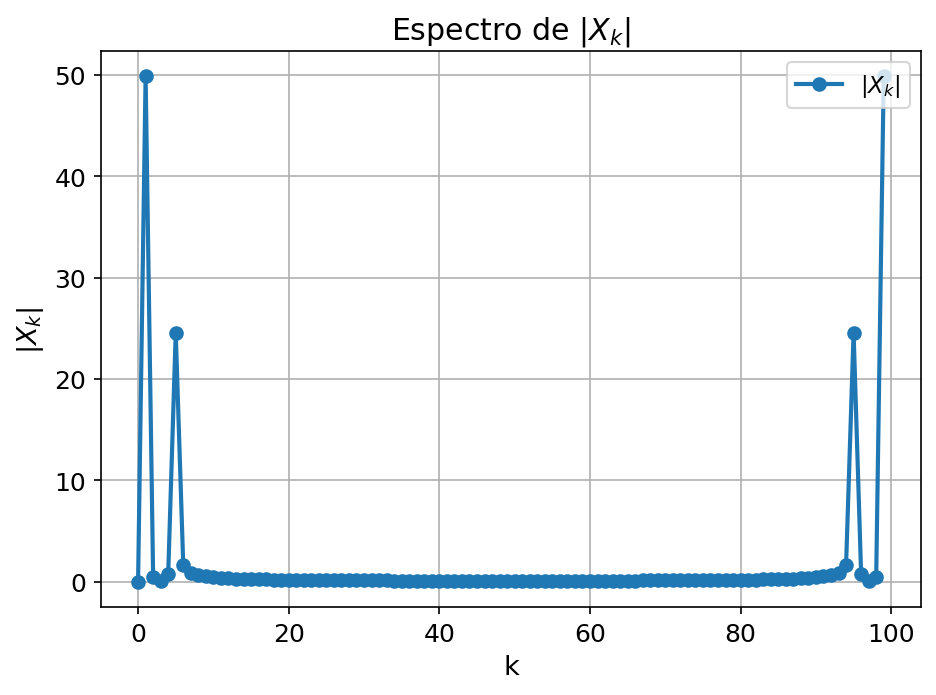

In [4]:
import matplotlib.pyplot as plt

#Defino Señal y su Transformada de Fourier

x_n, tiempos=señal(Pasos, t_final, f1, f2)                   #Señal para ciertos valores
X_k=TFdirecta(x_n)                                  #Transformada de Fourier para tales valores

#Calculo de |X_{k}|

Tfdirecta_abs=np.abs(X_k)

#Lista de k para grafico de X_k vs k

k = list(range(len(X_k)))

#Grafico

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

plt.figure()

plt.plot(k, Tfdirecta_abs, label=r"$|X_k|$", linewidth=2, marker='o', zorder=2)

plt.xlabel("k")
plt.ylabel(r"$|X_k|$")
plt.title("Espectro de |$X_{k}$|")

plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

(d) Calcule la transformada usando el algoritmo numpy.fft.fft.

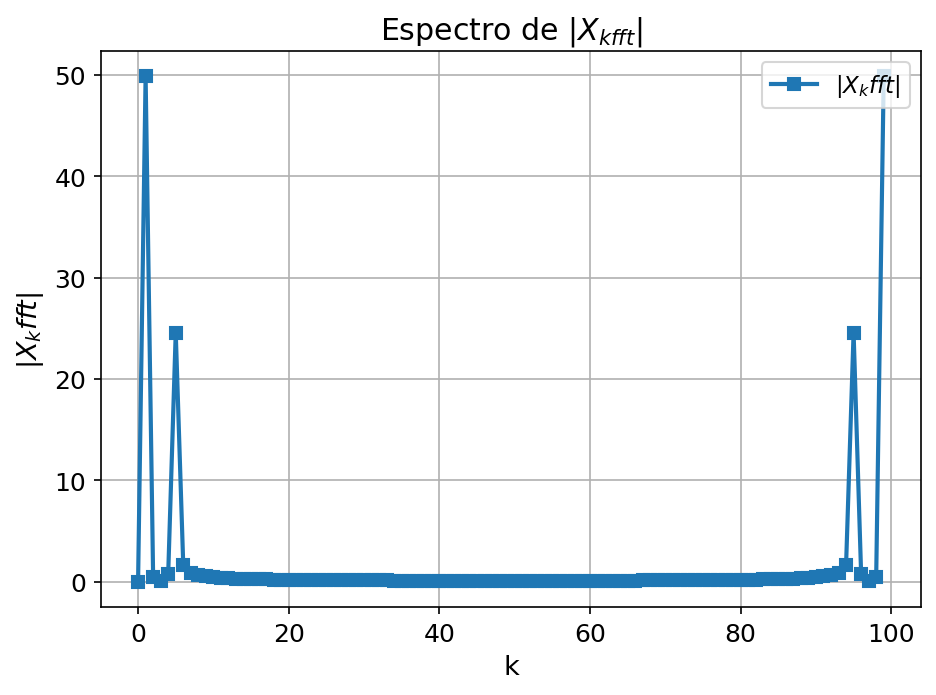

In [5]:
#Utilizamos el arreglo de las señales para construir su transformada de Fourier mediante numpy.fft.fft

X_kfft=np.fft.fft(x_n)
X_kfft_abs=np.abs(X_kfft)                         

# Grafico 

plt.figure()

plt.plot(k, X_kfft_abs, label=r"$|X_kfft|$", linewidth=2, marker='s', zorder=3)

plt.xlabel("k")
plt.ylabel(r"$|X_kfft|$")
plt.title("Espectro de |$X_{kfft}$|")

plt.legend(loc="upper right")

plt.tight_layout()
plt.show()


(e) Compare el tiempo de ejecucion entre su implementacion directa de la DFT y el algoritmo FFT para distintos tamaños de señal (N = 10^2, 10^3, 10^4, 10^5).

In [7]:
import time                           #Nos permitira tomar el tiempo de ejecucion

Ns=[10**2, 10**3, 10**4]       #Lista con los valores de los tamaños de la señal (Lo hago de 10^2 a 10^4 porque 10^5 no termino nunca de ejecutarse el codigo)

#Arreglo de tiempos de ejecucion para forma directa y a traves de numpy.fft.fft

t_direc=[]
t_fft=[]

#Ciclo para calcular tiempos de ejecucion

for i in Ns:
    x_n, tiempos=señal(i, t_final, f1, f2)            #Calculo arreglos de señal y tiempos para cierto tamaño de señal i

    tic1=time.time()                                  #Inicializacion del tiempo de ejecucion             
    X_k=TFdirecta(x_n)                                #Calculo de transforamada de Fourier de forma directa
    tic2=time.time()                                  #Finalizacion del tiempo de ejecucion
    t_direc.append(tic2-tic1)

    tic3=time.time()
    X_kfft=np.fft.fft(x_n)                            #Calculo de transforma de Fourier a traves de numpy.fft.fft
    tic4=time.time()
    t_fft.append(tic4-tic3)

for i in range(len(Ns)):                              #Ciclo para comparar tiempos de ejecucion
    print(f"N = {Ns[i]} | Forma directa: {t_direc[i]:.6f} s | Forma numpy.fft.fft: {t_fft[i]:.6f} s")             #.6f: muestra hasta 6 decimales

N = 100 | Forma directa: 0.028305 s | Forma numpy.fft.fft: 0.000076 s
N = 1000 | Forma directa: 2.701826 s | Forma numpy.fft.fft: 0.000118 s
N = 10000 | Forma directa: 269.954934 s | Forma numpy.fft.fft: 0.001281 s


(f) Grafique el tiempo de ejecucion en funcion de N para ambos algoritmos.

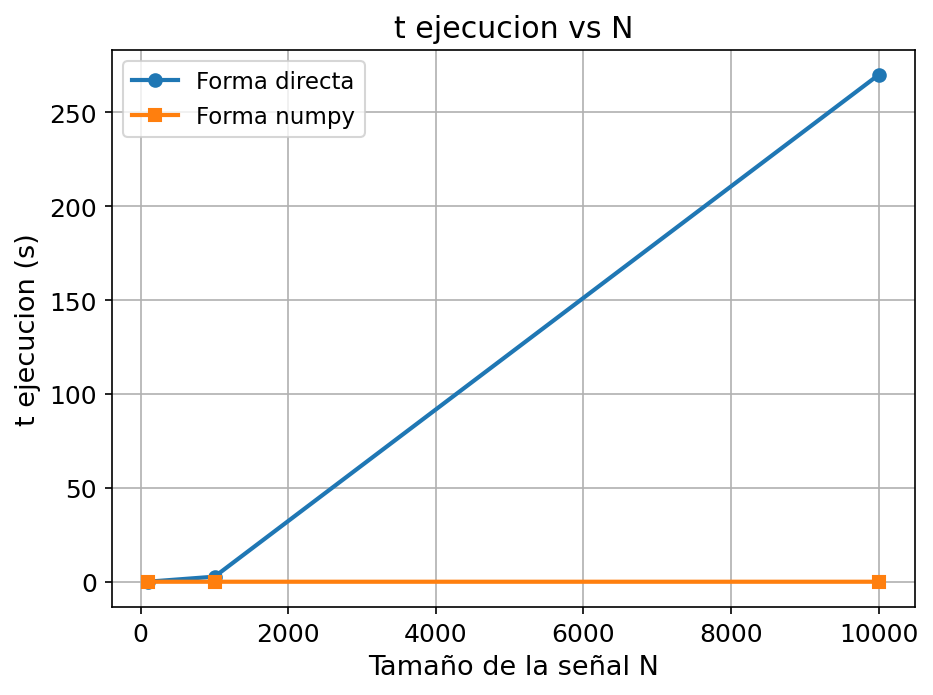

In [8]:
#Grafico

plt.figure()

plt.plot(Ns, t_direc, label="Forma directa", marker='o', linewidth=2)
plt.plot(Ns, t_fft, label="Forma numpy", marker='s', linewidth=2)

plt.xlabel("Tamaño de la señal N")
plt.ylabel("t ejecucion (s)")
plt.title("t ejecucion vs N")

plt.legend()
plt.tight_layout()
plt.show()

(g) Repita el grafico en escala log-log y estime experimentalmente el exponente de escalamiento de cada algoritmo.

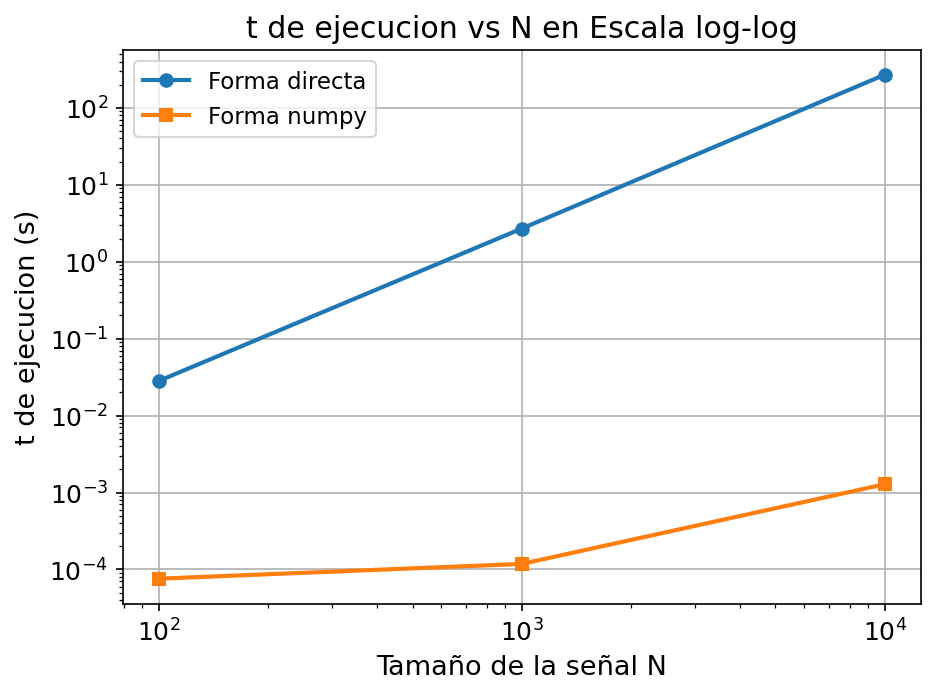

In [9]:
#Grafico en Log

plt.figure()

plt.plot(Ns, t_direc, label="Forma directa", marker='o', linewidth=2)
plt.plot(Ns, t_fft, label="Forma numpy", marker='s', linewidth=2)

plt.xlabel("Tamaño de la señal N")
plt.ylabel("t de ejecucion (s)")
plt.title("t de ejecucion vs N en Escala log-log")

plt.legend()

plt.xscale("log")                      #Introducimos escala Log
plt.yscale("log")

plt.tight_layout()
plt.show()

Ahora, para estimar el exponente de escalamiento de cada algoritmo recordamos que podemos decir que el tiempo de ejecucion es tal que:  

$t(N) \approx N^{\mu}$  

donde $\mu$ es el exponente de escalamiento. Esto es porque la construccion del tiempo de ejecucion de cualquier algoritmo tiene forma de polinomios. Entonces, si definimos:  

$t_{1}(N_{1})=N_{1}^{\mu}$  
$t_{2}(N_{2})=N_{2}^{\mu}$  

donde $t_{2} es mayor que $t_{1}$. Luego, si:  

$\frac{t_{2}}{t_{1}}=\left( \frac{N_{2}}{N_{1}} \right)^{\mu}$  
$\ln(\frac{t_{2}}{t_{1}})=\mu \ln(\frac{N_{2}}{N_{1}})$  

Por tanto, obtenemos que el exponente de escalamiento es:  

$\mu=\frac{\ln(\frac{t_{2}}{t_{1}})}{\ln(\frac{N_{2}}{N_{1}})}$  

Entonces, experimentalmente, aplicando esta formula al caso directo y al caso fft:  

In [13]:
Exp_esc_direc=np.log(t_direc[2] / t_direc[1]) / np.log(Ns[2] / Ns[1])         #Para caso directo
Exp_esc_fft=np.log(t_fft[2] / t_fft[1]) / np.log(Ns[2] / Ns[1])               #Para caso fft

print(f"Forma directa: mu ≈ {Exp_esc_direc:.2f}")
print(f"Forma fft: mu ≈ {Exp_esc_fft:.2f}")

Forma directa: mu ≈ 2.00
Forma fft: mu ≈ 1.04


(h) Determine aproximadamente para que valor de N la FFT se vuelve al menos 100 veces mas rapida que la DFT directa.  

Con el resultado del inciso anterior y aproximando, obtenemos:  

$t_{FFT}(N) \approx N$  
$t_{D}(N) \approx N^{2}$

donde la primera relacion es para la forma fft y la segunda para la forma directa. Buscamos que:  

$\frac{t_{FFT}}{t_{D}} \approx 0.01$  

Si $N=100$, se tiene que:

$\frac{t_{FFT}}{t_{D}} \approx \frac{100}{100^{2}} = 0.01$  

Lo que indica que, aproximadamente, para valores de $N$ mayores o iguales a $100$ la FFT se vuelve al menos $100$ veces mas rapida que la DFT directa.




(i) Explique por que el algoritmo FFT ha sido fundamental para el desarrollo de simulaciones en fısica, procesamiento de señales y analisis de datos experimentales.  

El algoritmo FFT es fundamental para la simulacion, procesamiento de señales y analisis de datos experimentales por su eficiencia. A traves del analisis anterior, es claro que la forma directa de calcular la transformada de Fourier, para un gran volumen de datos (como suele ser normalmente), puede llegar a ser inviable para un gran numero de datos. A traves del algoritmo FFT se reduce el costo computacional de aproximadamente $N^{2}$ a $N$, donde $N$ es el numero de datos que analicemos. Lo que permite analizar grandes señales en un lapso de tiempo tratable.